# XAI Analysis â€” SHAP Explainability | C-MAPSS FD001
Global and local explanation of XGBoost RUL predictions using SHAP.

1. Import Libraries and Project Modules

In [1]:
# standard
from pathlib import Path

# 3rd party
import pandas as pd

# project
from xai_aviation_rul.data_loader import load_cmapss
from xai_aviation_rul.explainer import (
    compute_shap_values,
    plot_shap_summary,
    plot_shap_waterfall,
)
from xai_aviation_rul.models import load_model
from xai_aviation_rul.preprocessor import (
    compute_rul,
    drop_constant_sensors,
    get_last_cycle,
    normalize,
)
from xai_aviation_rul.visualizer import save_table_as_figure

# figure save paths
FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

2. Prepare Data

In [2]:
# load raw train and test sets
df_train = load_cmapss(fd=1, subset="train")
df_test  = load_cmapss(fd=1, subset="test")

# compute RUL labels and apply 125-cycle cap
df_train = compute_rul(df_train, rul_cap=125)

# remove constant sensors
df_train = drop_constant_sensors(df_train, threshold=0.01)

# fit scaler on train
df_train, df_test, scaler = normalize(df_train, df_test)

# remaining sensor columns after preprocessing
sensor_cols = [c for c in df_train.columns if c.startswith("sensor_")]

# extract last cycle per engine
df_last = get_last_cycle(df_test)
X_test  = df_last[sensor_cols]

# load trained XGBoost model from disk
xgb_model = load_model("../models/xgboost_model.pkl")

3. Compute SHAP Values

In [3]:
# compute SHAP values for test set
shap_values, explainer = compute_shap_values(xgb_model, X_test)

print(f"SHAP values shape:{shap_values.shape}")
print(f"Explainer type: {type(explainer)}")
print(f"Base value (expected model output): {explainer.expected_value:.3f}")

SHAP values shape:(100, 14)
Explainer type: <class 'shap.explainers._tree.TreeExplainer'>
Base value (expected model output): 86.834


3. Global SHAP Summary Plot

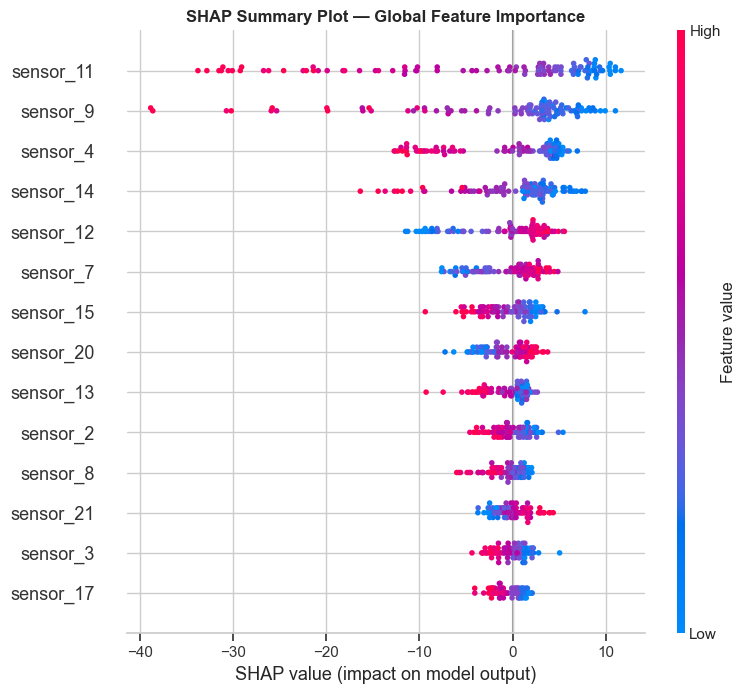

SHAP summary plot saved to: figures\fig_shap_summary.png


In [4]:
# generate and save SHAP summary plot
plot_shap_summary(
    shap_values,
    X_test,
    save_path=FIG_DIR / "fig_shap_summary.png"
)
print(f"SHAP summary plot saved to: {FIG_DIR/'fig_shap_summary.png'}")

4. Local SHAP Waterfall Plot - Engine with Lowest Predicted RUL

In [5]:
# find engine with lowest predicted RUL
predictions = xgb_model.predict(X_test)
lowest_rul_idx = int(predictions.argmin())
engine_number = int(df_last.iloc[lowest_rul_idx]["unit_number"])

# save critical engine summary
critical_engine_table = pd.DataFrame([{
    "Engine Number": engine_number,
    "Predicted RUL (cycles)": round(float(predictions[lowest_rul_idx]), 2),
    "Last Recorded Cycle": int(df_last.iloc[lowest_rul_idx]["time_in_cycles"]),
}]).T.rename(columns={0: "Value"}).rename_axis("Metric")

Tabular Representation of Critical Engine

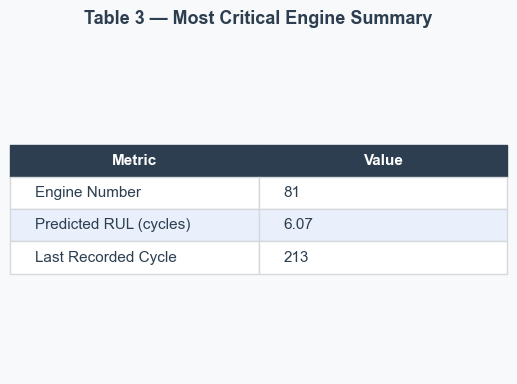

Critical engine summary table saved to: figures\table3_critical_engine.png


In [6]:
# table for critical engine summary
save_table_as_figure(
    critical_engine_table,
    save_path=FIG_DIR / "table3_critical_engine.png",
    title="Table 3 â€” Most Critical Engine Summary"
)
print(f"Critical engine summary table saved to: {FIG_DIR/'table3_critical_engine.png'}")

Local SHAP Waterfall Representation for Most Critical Engine

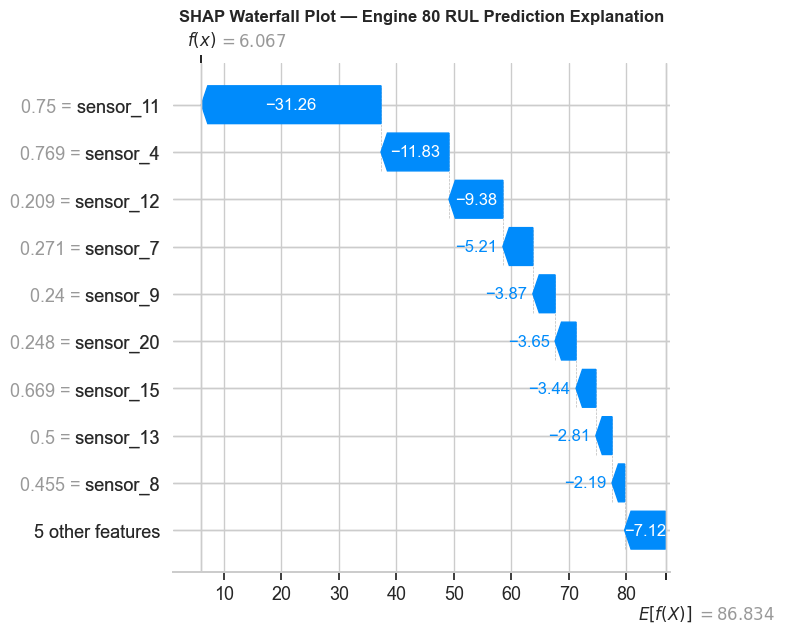

SHAP waterfall plot for critical engine saved to: figures\fig_shap_waterfall.png


In [7]:
# waterfall plot for the most critical engine
plot_shap_waterfall(explainer, shap_values, X_test, lowest_rul_idx,
                    save_path=FIG_DIR / "fig_shap_waterfall.png")
waterfall_file = FIG_DIR / "fig_shap_waterfall.png"
print(f"SHAP waterfall plot for critical engine saved to: {waterfall_file}")